# Práctica 2: Aprendizaje no supervisado
## Determinación de tipos de estrellas

**Asignatura:** Aprendizaje Automático  
**Integrantes:** Jose Luis Mejía Acuña, Mireya Luque Perez  
**Semilla base utilizada:** 100495927

## 1. Objetivo

El objetivo de esta práctica es aplicar técnicas de aprendizaje no supervisado para
agrupar estrellas en función de sus características físicas y espectrales.

Para ello, se parte de un conjunto de datos de 240 estrellas y se comparan tres
algoritmos de clustering:
- K-Means
- Clustering jerárquico
- DBSCAN

Siguiendo el enunciado, antes del clustering se reduce la dimensionalidad a 2
componentes principales mediante PCA. Finalmente, se recomienda un pipeline de
clustering y se compara con las clases astronómicas habituales.


In [1]:
# Instalación de dependencias necesarias
%pip install numpy pandas matplotlib seaborn scikit-learn scipy hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 11.3 MB/s eta 0:00:00 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from hdbscan.validity import validity_index
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram

SEED = 100495927  
np.random.seed(SEED)

En esta práctica se fija una semilla para garantizar la reproducibilidad de los
resultados, tal y como exige el enunciado.

In [3]:
df = pd.read_csv("stars_data.csv")  # revisar nombre exacto del fichero
df.head()

,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [4]:
df.shape, df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


((240, 6), None)

In [5]:
df.describe(include='all')

,Temperature,L,R,A_M,Color,Spectral_Class
count,240.000000,240.000000,240.000000,240.000000,240,240
unique,NaN,NaN,NaN,NaN,17,7
top,NaN,NaN,NaN,NaN,Red,M
freq,NaN,NaN,NaN,NaN,112,111
mean,10497.462500,107188.361635,237.157781,4.382396,NaN,NaN
std,9552.425037,179432.244940,517.155763,10.532512,NaN,NaN
min,1939.000000,0.000080,0.008400,-11.920000,NaN,NaN
25%,3344.250000,0.000865,0.102750,-6.232500,NaN,NaN
50%,5776.000000,0.070500,0.762500,8.313000,NaN,NaN
75%,15055.500000,198050.000000,42.750000,13.697500,NaN,NaN


# 3. Descripción inicial del dataset

El conjunto de datos contiene 240 estrellas y las siguientes variables:
- **Temperature**: Temperatura promedio de la superficie en grados K
- **L**: Luminosidad comparada con el Sol
- **R**: Radio comparado con la del Sol
- **A_M**: Magnitud absoluta 
- **Spectral_Class**: Clasificación espectral
- **Color**: Color principal del espectro

A continuación se revisan tipos de datos, posibles valores categóricos y la existencia
de valores perdidos o inconsistencias.

## 3.1: Limpieza y Consolidación de Datos

Antes de aplicar cualquier algoritmo, es fundamental la calidad de los datos. En este paso comprobaremos la existencia de **valores nulos** o **registros duplicados** que puedan alterar la formación de los clusters.

Además en conjuntos de datos astronómicos es común encontrar inconsistencias tipográficas en variables categóricas introducidas manualmente, como el color de la estrella. Procedemos a estandarizar la variable `Color` (convirtiendo todo a minúsculas y eliminando espacios/guiones redundantes) para evitar que el algoritmo interprete "Red" y "red" como dos categorías distintas.

In [ ]:
print("1. COMPROBACIÓN DE NULOS Y DUPLICADOS")
print(f"Valores nulos por columna:\n{df.isnull().sum()}\n")
print(f"Filas duplicadas: {df.duplicated().sum()}\n")

print("2. LIMPIEZA DE LA VARIABLE 'Color'")
# Estandarizamos los colores: minúsculas, quitamos espacios extra y cambiamos guiones por espacios
df['Color'] = df['Color'].str.lower().str.strip().str.replace('-', ' ')
print("Valores únicos de Color tras la limpieza:")
print(df['Color'].value_counts())

print("\n3. VALORES DE 'Spectral_Class'")
print(df['Spectral_Class'].value_counts())

1. COMPROBACIÓN DE NULOS Y DUPLICADOS
Valores nulos por columna:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

Filas duplicadas: 0

2. LIMPIEZA DE LA VARIABLE 'Color'
Valores únicos de Color tras la limpieza:
Color
red                   112
blue                   56
blue white             41
white                  10
yellow white            8
yellowish white         3
yellowish               3
whitish                 2
orange                  2
pale yellow orange      1
white yellow            1
orange red              1
Name: count, dtype: int64

3. VALORES DE 'Spectral_Class'
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64


## 3.2: Análisis Visual: Diagrama Hertzsprung-Russell (HR)

A modo de investigación, vamos a recrear el diagrama más importante de la astrofísica estelar: el *Diagrama Hertzsprung-Russell (HR)*.

Este gráfico es importante porque nos va a mostrar agrupaciones naturales que los algoritmos de clustering no supervisado generarán más adelante. **¿Cómo funciona?** El gráfico relaciona la `Temperatura superficial` (eje X) con la `Magnitud Absoluta` o luminosidad (eje Y). Las estrellas más calientes quedarán a la izquierda (invertiremos los ejes) y las más brillantes en la parte superior.

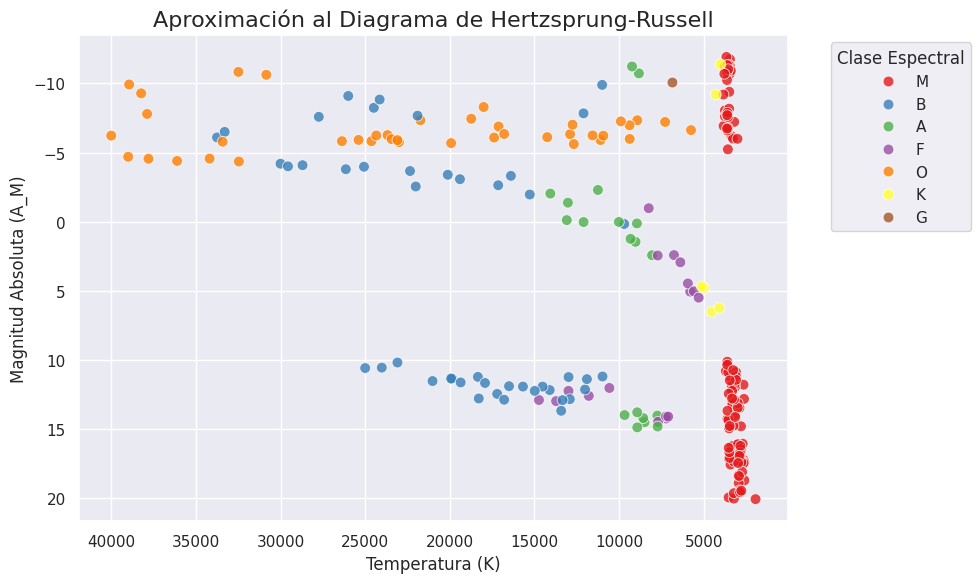

In [7]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

#Dibujamos Temperatura vs Magnitud Absoluta
sns.scatterplot(data=df, x='Temperature', y='A_M', hue='Spectral_Class', palette='Set1', s=60, alpha=0.8)

#Para que cumpla el estándar astronómico, invertimos los ejes
plt.gca().invert_xaxis()  
plt.gca().invert_yaxis() 

plt.title("Aproximación al Diagrama de Hertzsprung-Russell", fontsize=16)
plt.xlabel("Temperatura (K)", fontsize=12)
plt.ylabel("Magnitud Absoluta (A_M)", fontsize=12)
plt.legend(title='Clase Espectral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3.3. Preprocesamiento: codificación ordinal y escalado

Los algoritmos de clustering que se van a aplicar se basan en distancias entre observaciones. Por ello, antes de aplicar PCA y clustering, es necesario transformar las variables categóricas y escalar las variables.

El enunciado indica que las variables categóricas `Color` y `Spectral_Class` deben codificarse de forma ordinal. Esto es importante porque ambas variables tienen una interpretación física:

- La clase espectral sigue una secuencia relacionada con la temperatura de la estrella, desde estrellas más frías hasta estrellas más calientes.
- El color también está relacionado con la energía y la temperatura superficial, desde tonos rojizos hasta tonos azulados.

Por tanto, no se utiliza One-Hot Encoding, ya que perdería el orden físico entre categorías. En su lugar, se aplica una codificación ordinal justificada.

In [8]:
print("PREPROCESAMIENTO PARA CLUSTERING")

# 1. Codificación ordinal de Spectral_Class
# Orden físico aproximado: M más fría, O más caliente
spectral_order = {
    "M": 0,
    "K": 1,
    "G": 2,
    "F": 3,
    "A": 4,
    "B": 5,
    "O": 6
}

# 2. Codificación ordinal de Color
# Orden aproximado de menor a mayor energía/temperatura
color_order = {
    "red": 0,
    "orange red": 1,
    "orange": 2,
    "pale yellow orange": 3,
    "yellowish": 4,
    "yellowish white": 5,
    "yellow white": 5,
    "white yellow": 5,
    "whitish": 6,
    "white": 6,
    "blue white": 7,
    "blue": 8
}

df["Spectral_Class_ord"] = df["Spectral_Class"].map(spectral_order)
df["Color_ord"] = df["Color"].map(color_order)

# 3. Comprobamos que no hayan quedado categorías sin codificar
print("Valores nulos tras codificación ordinal:")
print(df[["Spectral_Class_ord", "Color_ord"]].isnull().sum())

# 4. Seleccionamos variables finales para PCA y clustering
columnas_modelo = [
    "Temperature",
    "L",
    "R",
    "A_M",
    "Spectral_Class_ord",
    "Color_ord"
]

df_modelo = df[columnas_modelo].copy()

display(df_modelo.head())
display(df_modelo.describe())

# 5. Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_modelo)

print(f"Dimensiones del dataset original: {df.shape}")
print(f"Dimensiones del dataset usado para PCA y clustering: {X_scaled.shape}")

PREPROCESAMIENTO PARA CLUSTERING
Valores nulos tras codificación ordinal:
Spectral_Class_ord    0
Color_ord             0
dtype: int64


,Temperature,L,R,A_M,Spectral_Class_ord,Color_ord
0,3068,0.002400,0.1700,16.12,0,0
1,3042,0.000500,0.1542,16.60,0,0
2,2600,0.000300,0.1020,18.70,0,0
3,2800,0.000200,0.1600,16.65,0,0
4,1939,0.000138,0.1030,20.06,0,0


,Temperature,L,R,A_M,Spectral_Class_ord,Color_ord
count,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.520833,3.695833
std,9552.425037,179432.244940,517.155763,10.532512,2.531720,3.608913
min,1939.000000,0.000080,0.008400,-11.920000,0.000000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,0.000000,0.000000
50%,5776.000000,0.070500,0.762500,8.313000,3.000000,5.000000
75%,15055.500000,198050.000000,42.750000,13.697500,5.000000,7.000000
max,40000.000000,849420.000000,1948.500000,20.060000,6.000000,8.000000


Dimensiones del dataset original: (240, 8)
Dimensiones del dataset usado para PCA y clustering: (240, 6)


# 4. Reducción de dimensionalidad con PCA

Siguiendo los requisitos de la práctica, se aplica PCA para reducir el conjunto de datos a 2 componentes principales.

Los algoritmos de clustering se aplicarán directamente sobre estas dos componentes principales. Esto permite visualizar los grupos en un plano 2D y comparar de forma homogénea los resultados de K-Means, clustering jerárquico y DBSCAN.

Antes de PCA se han escalado las variables para evitar que aquellas con magnitudes mayores, como la temperatura o la luminosidad, dominen el cálculo de las componentes principales.

4. REDUCCIÓN DE DIMENSIONALIDAD: PCA a 2D
Varianza explicada por PC1: 55.42%
Varianza explicada por PC2: 29.70%
Varianza total retenida en 2D: 85.12%


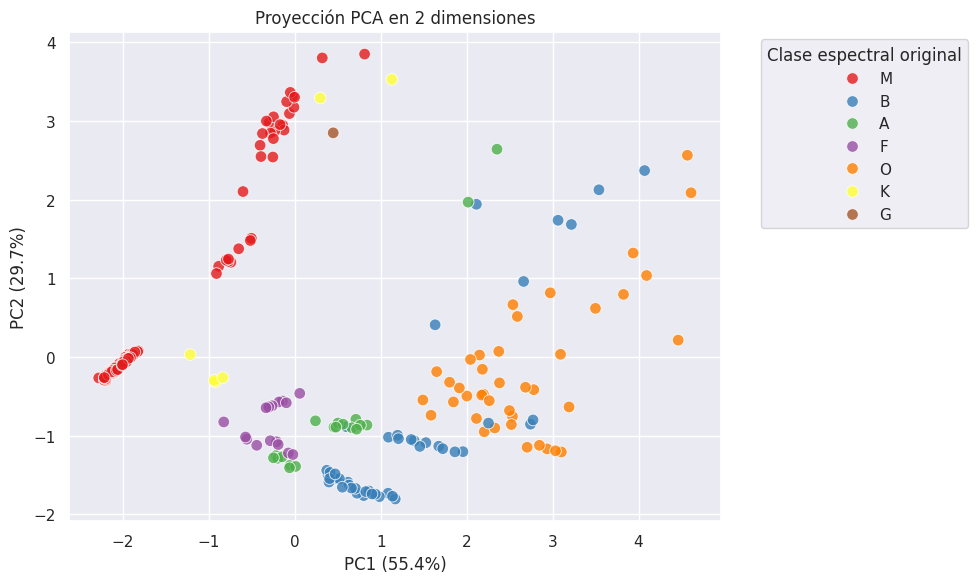

In [9]:
print("4. REDUCCIÓN DE DIMENSIONALIDAD: PCA a 2D")

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

varianza_explicada = pca.explained_variance_ratio_

print(f"Varianza explicada por PC1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza total retenida en 2D: {sum(varianza_explicada)*100:.2f}%")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    hue=df["Spectral_Class"],
    palette="Set1",
    s=70,
    alpha=0.8
)
plt.title("Proyección PCA en 2 dimensiones")
plt.xlabel(f"PC1 ({varianza_explicada[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({varianza_explicada[1]*100:.1f}%)")
plt.legend(title="Clase espectral original", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [10]:
def evaluar_clustering(X, labels):
    """
    Calcula métricas internas de clustering.
    Ignora soluciones con menos de 2 clusters válidos.
    """
    labels = np.array(labels)
    clusters = set(labels)

    # No contamos el ruido de DBSCAN como cluster real
    clusters_sin_ruido = clusters - {-1}
    n_clusters = len(clusters_sin_ruido)
    n_ruido = np.sum(labels == -1)

    if n_clusters < 2:
        return {
            "n_clusters": n_clusters,
            "n_ruido": n_ruido,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan
        }

    # Para las métricas tradicionales, quitamos ruido si existe
    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]

    return {
        "n_clusters": n_clusters,
        "n_ruido": n_ruido,
        "silhouette": silhouette_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval)
    }

# 5. K-Means

Se aplica K-Means sobre las dos componentes principales obtenidas mediante PCA. Para seleccionar el número de clusters se prueban distintos valores de `k` y se comparan mediante métricas internas: Silhouette, Calinski-Harabasz y Davies-Bouldin.

In [11]:
resultados_kmeans = []

for k in range(2, 11):
    modelo = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = modelo.fit_predict(X_pca)

    metricas = evaluar_clustering(X_pca, labels)
    metricas["k"] = k
    resultados_kmeans.append(metricas)

resultados_kmeans = pd.DataFrame(resultados_kmeans)
resultados_kmeans = resultados_kmeans[[
    "k",
    "n_clusters",
    "n_ruido",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin"
]]

display(resultados_kmeans)

,k,n_clusters,n_ruido,silhouette,calinski_harabasz,davies_bouldin
0,2,2,0,0.512907,240.440280,0.856265
1,3,3,0,0.587652,311.163707,0.655842
2,4,4,0,0.634594,493.934768,0.574125
3,5,5,0,0.652735,630.617345,0.552317
4,6,6,0,0.660530,664.034697,0.505699
5,7,7,0,0.643249,724.400028,0.558628
6,8,8,0,0.637282,733.254305,0.670667
7,9,9,0,0.612008,732.738077,0.739676
8,10,10,0,0.614976,737.001663,0.673023


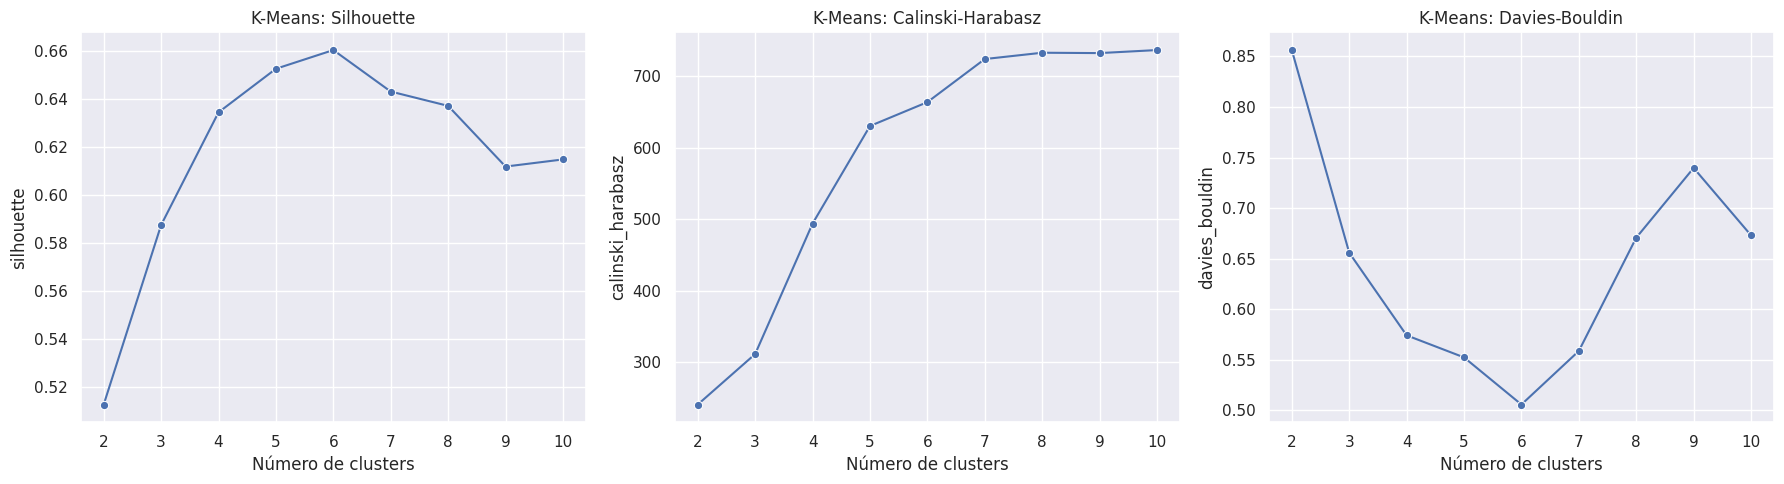

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=resultados_kmeans, x="k", y="silhouette", marker="o", ax=axes[0])
axes[0].set_title("K-Means: Silhouette")
axes[0].set_xlabel("Número de clusters")

sns.lineplot(data=resultados_kmeans, x="k", y="calinski_harabasz", marker="o", ax=axes[1])
axes[1].set_title("K-Means: Calinski-Harabasz")
axes[1].set_xlabel("Número de clusters")

sns.lineplot(data=resultados_kmeans, x="k", y="davies_bouldin", marker="o", ax=axes[2])
axes[2].set_title("K-Means: Davies-Bouldin")
axes[2].set_xlabel("Número de clusters")

plt.tight_layout()
plt.show()

Mejor k según Silhouette: 6


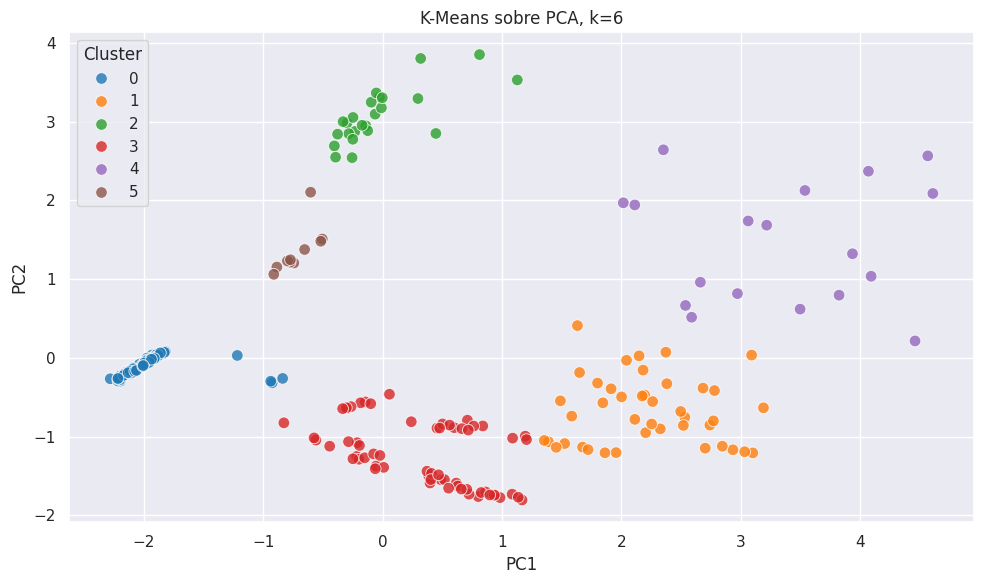

In [ ]:
mejor_k_kmeans = int(resultados_kmeans.sort_values("silhouette", ascending=False).iloc[0]["k"])

kmeans_final = KMeans(n_clusters=mejor_k_kmeans, random_state=SEED, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_pca)

print(f"Mejor k según Silhouette: {mejor_k_kmeans}")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    hue=labels_kmeans,
    palette="tab10",
    s=70,
    alpha=0.8
)
plt.title(f"K-Means sobre PCA, k={mejor_k_kmeans}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## Discusión de K-Means

K-Means se ha aplicado sobre las dos componentes principales obtenidas mediante PCA, tal y como requiere la práctica. Para seleccionar el número de clusters se han probado distintos valores de `k`, desde 2 hasta 10, evaluando cada configuración mediante Silhouette, Calinski-Harabasz y Davies-Bouldin.

El mejor resultado según Silhouette se obtiene con `k=6`. Esta configuración presenta una separación clara entre grupos en el plano PCA y, además, genera un número de clusters coherente con las seis clases astronómicas de referencia que aparecen en el enunciado.

K-Means es un método sencillo e interpretable, especialmente adecuado cuando se buscan grupos compactos. Su principal limitación es que tiende a asumir clusters de forma aproximadamente circular o convexa, por lo que puede tener dificultades si los grupos reales tienen formas complejas. Aun así, en este caso ofrece una solución estable, clara y fácil de comparar con las clases astronómicas.

# 6. Clustering jerárquico

Se aplica clustering jerárquico aglomerativo sobre las dos componentes principales. Se prueban distintos valores de `k` y distintos criterios de linkage para seleccionar una configuración razonable.

In [14]:
linkages = ["ward", "complete", "average", "single"]
resultados_hc = []

for link in linkages:
    for k in range(2, 11):
        modelo = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = modelo.fit_predict(X_pca)

        metricas = evaluar_clustering(X_pca, labels)
        metricas["k"] = k
        metricas["linkage"] = link
        resultados_hc.append(metricas)

resultados_hc = pd.DataFrame(resultados_hc)
resultados_hc = resultados_hc[[
    "linkage",
    "k",
    "n_clusters",
    "n_ruido",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin"
]]

display(resultados_hc.sort_values("silhouette", ascending=False).head(10))

,linkage,k,n_clusters,n_ruido,silhouette,calinski_harabasz,davies_bouldin
4,ward,6,6,0,0.648558,603.293622,0.507691
3,ward,5,5,0,0.640031,585.694077,0.566082
21,average,5,5,0,0.635680,583.355621,0.568205
24,average,8,8,0,0.634825,517.504679,0.604928
23,average,7,7,0,0.633174,548.626254,0.553357
5,ward,7,7,0,0.629386,661.708842,0.558325
22,average,6,6,0,0.627370,498.943500,0.605641
25,average,9,9,0,0.625578,475.509190,0.537802
6,ward,8,8,0,0.620685,661.958432,0.671468
20,average,4,4,0,0.620555,404.068154,0.535602


Mejor configuración jerárquica: k=6, linkage=ward


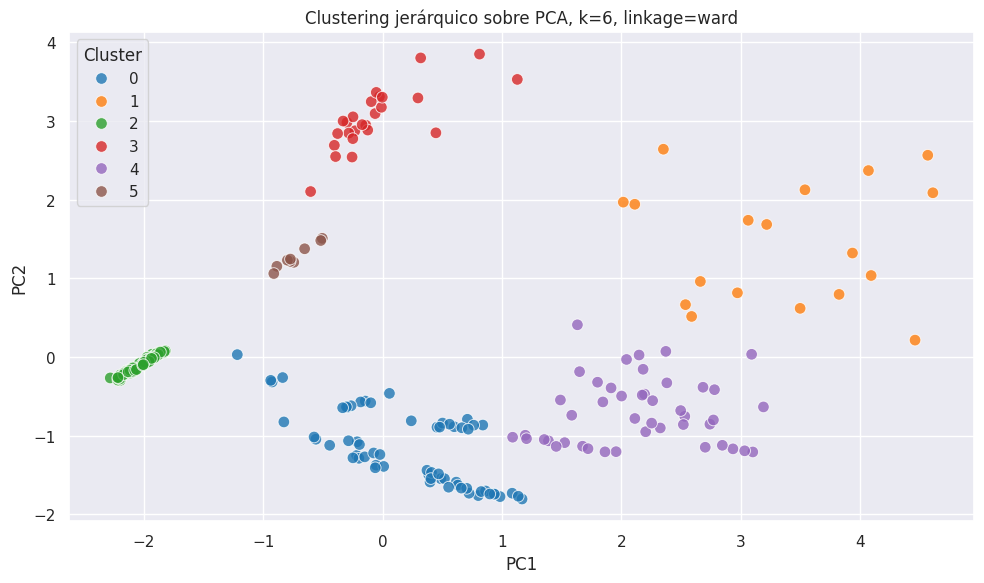

In [15]:
mejor_hc = resultados_hc.sort_values("silhouette", ascending=False).iloc[0]

mejor_k_hc = int(mejor_hc["k"])
mejor_linkage_hc = mejor_hc["linkage"]

hc_final = AgglomerativeClustering(
    n_clusters=mejor_k_hc,
    linkage=mejor_linkage_hc
)

labels_hc = hc_final.fit_predict(X_pca)

print(f"Mejor configuración jerárquica: k={mejor_k_hc}, linkage={mejor_linkage_hc}")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    hue=labels_hc,
    palette="tab10",
    s=70,
    alpha=0.8
)
plt.title(f"Clustering jerárquico sobre PCA, k={mejor_k_hc}, linkage={mejor_linkage_hc}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## Discusión del clustering jerárquico

El clustering jerárquico se ha aplicado sobre la representación PCA de dos dimensiones. Se han probado distintos números de clusters y diferentes criterios de enlace, comparando los resultados mediante métricas internas.

La mejor configuración obtenida es `k=6` con `linkage='ward'`. Este resultado es especialmente interesante porque coincide con el número de clusters seleccionado por K-Means. Esto sugiere que la estructura de los datos presenta una división razonable en seis grupos.

El método jerárquico tiene la ventaja de permitir estudiar la formación progresiva de los clusters mediante el dendrograma. Además, no depende de una inicialización aleatoria como K-Means. Sin embargo, una vez realizada la agrupación, puede ser menos flexible ante estructuras complejas y también depende de la elección del criterio de enlace.

En conjunto, el clustering jerárquico confirma que una solución con seis grupos es razonable para este conjunto de datos.

# 7. DBSCAN

DBSCAN permite encontrar clusters basados en densidad y detectar puntos de ruido. Sus hiperparámetros principales son:

- `eps`: radio máximo de vecindad.
- `min_samples`: número mínimo de puntos necesarios para formar una región densa.

Para seleccionar sus hiperparámetros se prueban distintas combinaciones y se evalúan con DBCV, tal y como pide el enunciado.

In [ ]:
resultados_dbscan = []

eps_values = np.arange(0.1, 3.1, 0.1)
min_samples_values = [3, 4, 5, 6, 8, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        modelo = DBSCAN(eps=eps, min_samples=min_samples)
        labels = modelo.fit_predict(X_pca)

        metricas = evaluar_clustering(X_pca, labels)

        try:
            if metricas["n_clusters"] >= 2:
                dbcv = validity_index(X_pca.astype(float), labels)
            else:
                dbcv = np.nan
        except Exception:
            dbcv = np.nan

        metricas["eps"] = eps
        metricas["min_samples"] = min_samples
        metricas["dbcv"] = dbcv
        resultados_dbscan.append(metricas)

resultados_dbscan = pd.DataFrame(resultados_dbscan)
resultados_dbscan = resultados_dbscan[[
    "eps",
    "min_samples",
    "n_clusters",
    "n_ruido",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "dbcv"
]]

display(resultados_dbscan.sort_values("dbcv", ascending=False).head(15))

,eps,min_samples,n_clusters,n_ruido,silhouette,calinski_harabasz,davies_bouldin,dbcv
27,0.5,6,4,26,0.685613,366.319239,0.382105,0.682524
28,0.5,8,4,27,0.689043,374.733543,0.378156,0.680626
26,0.5,5,4,23,0.673657,335.933269,0.396817,0.665051
6,0.2,3,13,39,0.721876,1509.401051,0.442972,0.634290
7,0.2,4,11,50,0.762850,1790.014824,0.430413,0.621961
15,0.3,6,9,40,0.728490,1471.383223,0.446377,0.611558
12,0.3,3,9,32,0.683073,989.597989,0.499389,0.607415
14,0.3,5,8,35,0.704576,1118.778850,0.530618,0.605377
13,0.3,4,8,35,0.704576,1118.778850,0.530618,0.605377
8,0.2,5,9,65,0.792899,1869.535542,0.343917,0.601219


Mejor configuración DBSCAN según DBCV:
eps=0.50, min_samples=6
Número de clusters: 4
Puntos marcados como ruido: 26


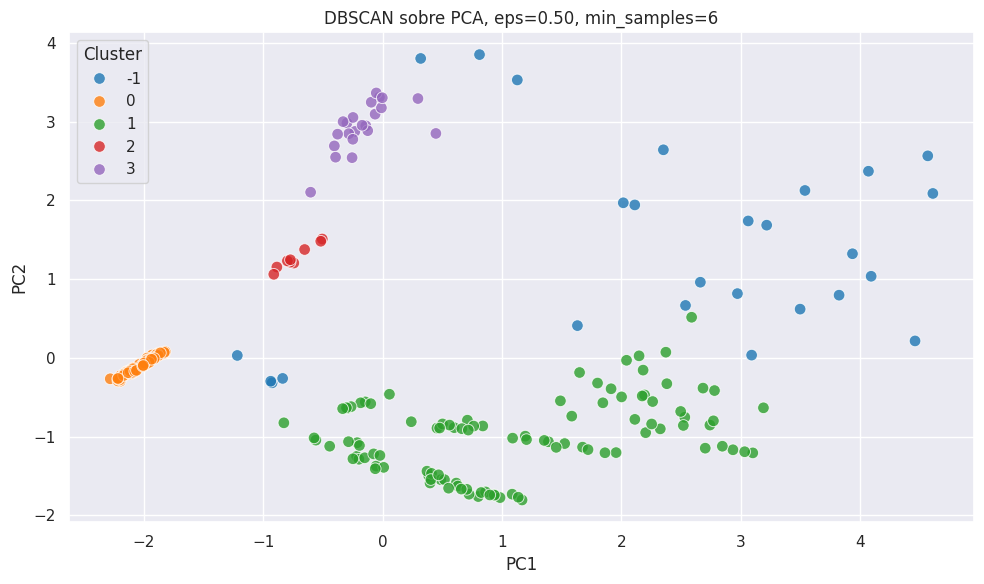

In [17]:
resultados_dbscan_validos = resultados_dbscan.dropna(subset=["dbcv"]).copy()

mejor_dbscan = resultados_dbscan_validos.sort_values("dbcv", ascending=False).iloc[0]

mejor_eps = float(mejor_dbscan["eps"])
mejor_min_samples = int(mejor_dbscan["min_samples"])

dbscan_final = DBSCAN(eps=mejor_eps, min_samples=mejor_min_samples)
labels_dbscan = dbscan_final.fit_predict(X_pca)

print(f"Mejor configuración DBSCAN según DBCV:")
print(f"eps={mejor_eps:.2f}, min_samples={mejor_min_samples}")
print(f"Número de clusters: {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")
print(f"Puntos marcados como ruido: {np.sum(labels_dbscan == -1)}")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    hue=labels_dbscan,
    palette="tab10",
    s=70,
    alpha=0.8
)
plt.title(f"DBSCAN sobre PCA, eps={mejor_eps:.2f}, min_samples={mejor_min_samples}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## Discusión de DBSCAN

DBSCAN se ha aplicado sobre las dos componentes principales obtenidas mediante PCA. A diferencia de K-Means y del clustering jerárquico, DBSCAN no necesita fijar previamente el número de clusters, sino que identifica grupos en función de la densidad de los puntos.

Para ajustar el modelo se han probado distintas combinaciones de `eps` y `min_samples`. La configuración seleccionada según DBCV es `eps=0.50` y `min_samples=6`.

DBSCAN obtiene buenos valores en algunas métricas, especialmente en Silhouette y DBCV. Sin embargo, genera únicamente 4 clusters y clasifica 26 estrellas como ruido. Esto significa que una parte relevante del conjunto de datos no queda asignada a ningún grupo final.

Este comportamiento puede ser útil cuando el objetivo principal es detectar anomalías o puntos aislados, pero resulta menos adecuado para esta práctica, donde se busca obtener una clasificación interpretable de todos los tipos de estrellas y compararla con las seis clases astronómicas de referencia.

# 8. Comparación global de algoritmos

En esta sección se comparan los mejores resultados obtenidos con K-Means, clustering jerárquico y DBSCAN.

In [18]:
metricas_kmeans = evaluar_clustering(X_pca, labels_kmeans)
metricas_hc = evaluar_clustering(X_pca, labels_hc)
metricas_dbscan = evaluar_clustering(X_pca, labels_dbscan)

comparacion = pd.DataFrame([
    {
        "Algoritmo": "K-Means",
        "Configuración": f"k={mejor_k_kmeans}",
        **metricas_kmeans,
        "DBCV": np.nan
    },
    {
        "Algoritmo": "Jerárquico",
        "Configuración": f"k={mejor_k_hc}, linkage={mejor_linkage_hc}",
        **metricas_hc,
        "DBCV": np.nan
    },
    {
        "Algoritmo": "DBSCAN",
        "Configuración": f"eps={mejor_eps:.2f}, min_samples={mejor_min_samples}",
        **metricas_dbscan,
        "DBCV": validity_index(X_pca.astype(float), labels_dbscan)
    }
])

display(comparacion)

,Algoritmo,Configuración,n_clusters,n_ruido,silhouette,calinski_harabasz,davies_bouldin,DBCV
0,K-Means,k=6,6,0,0.660530,664.034697,0.505699,NaN
1,Jerárquico,"k=6, linkage=ward",6,0,0.648558,603.293622,0.507691,NaN
2,DBSCAN,"eps=0.50, min_samples=6",4,26,0.685613,366.319239,0.382105,0.682524


## Discusión comparativa de los algoritmos

Los tres algoritmos aplicados permiten obtener agrupaciones razonables sobre la representación PCA de los datos, pero presentan comportamientos diferentes.

K-Means con `k=6` obtiene una solución clara, interpretable y sin puntos sin clasificar. Además, presenta un valor alto de Silhouette y el mejor valor de Calinski-Harabasz entre los modelos comparados. El hecho de que produzca seis clusters facilita la comparación directa con las seis clases astronómicas de referencia.

El clustering jerárquico también obtiene su mejor configuración con `k=6` y `linkage='ward'`. Sus resultados son muy similares a los de K-Means, lo que refuerza la idea de que existe una estructura natural de seis grupos en los datos. Además, el dendrograma permite visualizar cómo se forman los clusters progresivamente.

DBSCAN obtiene buenos valores en algunas métricas, especialmente en DBCV, que es la métrica específica utilizada para evaluar este método. Sin embargo, su mejor configuración genera solo 4 clusters y marca 26 estrellas como ruido. Esto reduce su utilidad como pipeline final, ya que no clasifica todas las estrellas y dificulta la comparación con la clasificación astronómica propuesta en el enunciado.

Por tanto, aunque DBSCAN tiene buenos resultados métricos, K-Means ofrece una solución más equilibrada para los objetivos de esta práctica: buena calidad de agrupamiento, interpretación sencilla, asignación de todas las estrellas a un cluster y correspondencia directa con las seis clases astronómicas de referencia.

# Pipeline recomendado

A partir de los resultados obtenidos, se recomienda el siguiente pipeline:

1. Limpieza de la variable `Color`, unificando formatos, espacios, mayúsculas y guiones.
2. Codificación ordinal de `Color` y `Spectral_Class`, respetando su interpretación física.
3. Escalado de las variables mediante `StandardScaler`.
4. Reducción de dimensionalidad a 2 componentes principales mediante PCA.
5. Aplicación de K-Means con `k=6`.

El algoritmo recomendado es K-Means con `k=6`.

Esta elección se justifica porque K-Means obtiene una solución clara, estable e interpretable. Aunque DBSCAN consigue buenos valores en algunas métricas, su mejor configuración genera únicamente 4 clusters y deja 26 estrellas clasificadas como ruido. Esto dificulta su uso como clasificación final, ya que parte de las estrellas quedarían sin grupo asignado.

K-Means, en cambio, asigna todas las estrellas a un cluster y obtiene seis grupos, el mismo número de clases astronómicas de referencia. Además, consigue un valor elevado de Silhouette y el mejor resultado de Calinski-Harabasz entre los modelos comparados. Por ello, ofrece el mejor equilibrio entre calidad de clustering, interpretabilidad y utilidad para la comparación astronómica posterior.

In [ ]:
algoritmo_recomendado = "kmeans" 

if algoritmo_recomendado == "kmeans":
    labels_finales = labels_kmeans
    descripcion_pipeline = f"K-Means con k={mejor_k_kmeans}"
elif algoritmo_recomendado == "jerarquico":
    labels_finales = labels_hc
    descripcion_pipeline = f"Clustering jerárquico con k={mejor_k_hc}, linkage={mejor_linkage_hc}"
elif algoritmo_recomendado == "dbscan":
    labels_finales = labels_dbscan
    descripcion_pipeline = f"DBSCAN con eps={mejor_eps:.2f}, min_samples={mejor_min_samples}"
else:
    raise ValueError("Algoritmo recomendado no válido")

print("Pipeline recomendado:")
print(descripcion_pipeline)

df_resultados = df.copy()
df_resultados["PC1"] = df_pca["PC1"]
df_resultados["PC2"] = df_pca["PC2"]
df_resultados["Cluster_final"] = labels_finales

display(df_resultados.head())

Pipeline recomendado:
K-Means con k=6


,Temperature,L,R,A_M,Color,Spectral_Class,Spectral_Class_ord,Color_ord,PC1,PC2,Cluster_final
0,3068,0.002400,0.1700,16.12,red,M,0,0,-2.076410,-0.141135,0
1,3042,0.000500,0.1542,16.60,red,M,0,0,-2.095980,-0.158994,0
2,2600,0.000300,0.1020,18.70,red,M,0,0,-2.197765,-0.229721,0
3,2800,0.000200,0.1600,16.65,red,M,0,0,-2.109804,-0.155463,0
4,1939,0.000138,0.1030,20.06,red,M,0,0,-2.282131,-0.267054,0


## Justificación del pipeline recomendado

El pipeline recomendado es K-Means con `k=6`, aplicado sobre las dos componentes principales obtenidas mediante PCA.

La elección se basa en tres criterios principales: calidad métrica, interpretabilidad y coherencia con el problema.

Desde el punto de vista métrico, K-Means obtiene una puntuación Silhouette elevada y el mejor valor de Calinski-Harabasz entre los modelos comparados. Esto indica que los clusters obtenidos están razonablemente separados y presentan una buena compacidad interna.

Desde el punto de vista interpretativo, K-Means genera seis clusters y asigna todas las estrellas a alguno de ellos. Esto facilita el análisis posterior, ya que permite estudiar el perfil medio de cada grupo sin dejar observaciones fuera.

Por último, desde el punto de vista astronómico, la solución con seis clusters es especialmente adecuada porque el enunciado propone seis clases de referencia: enana roja, enana marrón, enana blanca, estrella en secuencia principal, supergigante e hipergigante.

Aunque DBSCAN obtiene buenos resultados en DBCV, su mejor configuración genera solo cuatro clusters y clasifica 26 estrellas como ruido. Por esta razón, se considera menos adecuado como pipeline final para esta práctica, aunque sigue siendo útil como método comparativo.

In [20]:
perfil_clusters = df_resultados.groupby("Cluster_final")[[
    "Temperature",
    "L",
    "R",
    "A_M",
    "Spectral_Class_ord",
    "Color_ord"
]].agg(["count", "mean", "median"])

display(perfil_clusters)

Temperature                            L                 \
                    count          mean   median count           mean   
Cluster_final                                                           
0                      84   3213.880952   3186.0    84       0.017488   
1                      42  21793.357143  22675.0    42  203221.857143   
2                      24   3782.375000   3612.0    24  245541.666667   
3                      62  12522.145161  12054.0    62     133.972957   
4                      18  24015.888889  24317.5    18  512365.611111   
5                      10   3466.800000   3574.5    10  206600.000000   

                                 R                            A_M             \
                      median count         mean      median count       mean   
Cluster_final                                                                  
0                   0.000968    84     0.261814     0.16050    84  14.599202   
1              203450.000000    42    52.883976    35.00000    42  -5.552738   
2              219000.000000    24  1391.875000  1384.50000    24  -9.916250   
3                   0.001275    62     1.254002     0.01222    62   8.415790   
4              471216.500000    18  1105.388889  1223.00000    18  -8.730667   
5              197500.000000    10   129.500000    37.00000    10  -6.798000   

                       Spectral_Class_ord                  Color_ord  \
                median              count      mean median     count   
Cluster_final                                                          
0              14.7830                 84  0.047619    0.0        84   
1              -5.9075                 42  5.714286    6.0        42   
2             -10.7000                 24  0.166667    0.0        24   
3              11.4500                 62  4.177419    4.0        62   
4              -8.5700                 18  5.444444    6.0        18   
5              -6.6700                 10  0.000000    0.0        10   

                                
                   mean median  
Cluster_final                   
0              0.154762    0.0  
1              7.761905    8.0  
2              0.166667    0.0  
3              6.596774    7.0  
4              7.500000    8.0  
5              0.000000    0.0

In [21]:
print("Distribución de clase espectral por cluster:")
display(pd.crosstab(df_resultados["Cluster_final"], df_resultados["Spectral_Class"]))

print("Distribución de color por cluster:")
display(pd.crosstab(df_resultados["Cluster_final"], df_resultados["Color"]))

Distribución de clase espectral por cluster:


Spectral_Class,A,B,F,G,K,M,O
Cluster_final,,,,,,,
0,0,0,0,0,4,80,0
1,0,12,0,0,0,0,30
2,0,0,0,1,2,21,0
3,17,28,17,0,0,0,0
4,2,6,0,0,0,0,10
5,0,0,0,0,0,10,0


Distribución de color por cluster:


Color,blue,blue white,orange,orange red,pale yellow orange,red,white,white yellow,whitish,yellow white,yellowish,yellowish white
Cluster_final,,,,,,,,,,,,
0,0,0,0,1,0,80,0,0,0,0,3,0
1,32,10,0,0,0,0,0,0,0,0,0,0
2,0,0,2,0,0,22,0,0,0,0,0,0
3,13,26,0,0,1,0,8,1,2,8,0,3
4,11,5,0,0,0,0,2,0,0,0,0,0
5,0,0,0,0,0,10,0,0,0,0,0,0


# 10. Comparación con clases astronómicas habituales

El enunciado proporciona una tabla con clases astronómicas típicas, como enanas rojas, enanas marrones, enanas blancas, estrellas de secuencia principal, supergigantes e hipergigantes.

Para comparar los clusters obtenidos con estas clases, se analizan las características medias de cada grupo: temperatura, luminosidad, radio, magnitud absoluta, color y clase espectral.

In [22]:
tabla_astronomica = pd.DataFrame({
    "Clase": [
        "Enana roja",
        "Enana marrón",
        "Enana blanca",
        "Secuencia principal",
        "Supergigante",
        "Hipergigante"
    ],
    "Temperatura_aprox": [3000, 3300, 14000, 16000, 15000, 11000],
    "L_aprox": [7e-4, 5.5e-3, 2.5e-3, 3.2e4, 3.0e5, 3.0e5],
    "R_aprox": [1e-1, 3.5e-1, 1e-2, 4.4, 5.0e1, 1.4e3],
    "A_M_aprox": [17.5, 12.5, 12.6, -0.4, -6.4, -9.6],
    "Color": [
        "rojo",
        "rojo",
        "blanco",
        "blanco-amarillo",
        "blanco-amarillo",
        "amarillo"
    ],
    "Clase_espectral": [
        "K-M",
        "M",
        "B-G",
        "B-M",
        "B-M",
        "B-M"
    ]
})

display(tabla_astronomica)

,Clase,Temperatura_aprox,L_aprox,R_aprox,A_M_aprox,Color,Clase_espectral
0,Enana roja,3000,0.0007,0.10,17.5,rojo,K-M
1,Enana marrón,3300,0.0055,0.35,12.5,rojo,M
2,Enana blanca,14000,0.0025,0.01,12.6,blanco,B-G
3,Secuencia principal,16000,32000.0000,4.40,-0.4,blanco-amarillo,B-M
4,Supergigante,15000,300000.0000,50.00,-6.4,blanco-amarillo,B-M
5,Hipergigante,11000,300000.0000,1400.00,-9.6,amarillo,B-M


## Discusión de similitudes con la clasificación astronómica

A partir del perfil medio de los clusters finales, se observan varias relaciones entre los grupos obtenidos mediante K-Means y las clases astronómicas habituales.

El cluster 0 agrupa principalmente estrellas de clase espectral M, color rojo, baja temperatura, baja luminosidad y radio reducido. Estas características son compatibles con estrellas frías y poco luminosas, por lo que este grupo puede relacionarse con enanas rojas o enanas marrones.

El cluster 3 contiene estrellas con temperaturas elevadas, colores blancos o azulados y radios reducidos. Estas propiedades pueden relacionarse con enanas blancas, que se caracterizan por tener alta temperatura, baja luminosidad relativa y radio pequeño.

El cluster 1 agrupa estrellas muy calientes, principalmente de clases espectrales O y B, con luminosidad elevada y radios grandes. Estas características lo acercan a estrellas masivas y brillantes, similares a supergigantes calientes.

El cluster 2 presenta temperaturas más bajas, colores rojizos, luminosidad muy elevada y radios extremadamente grandes. Esto sugiere una posible relación con estrellas gigantes o hipergigantes rojas.

El cluster 4 contiene estrellas con temperaturas altas, colores azulados, gran luminosidad y radios elevados. Por ello, puede asociarse con estrellas supergigantes o hipergigantes calientes.

El cluster 5 agrupa estrellas rojas de clase espectral M con alta luminosidad y radio elevado, por lo que puede interpretarse como un grupo próximo a supergigantes rojas.

La correspondencia entre clusters y clases astronómicas no es perfecta. Esto es esperable, ya que los grupos se han obtenido mediante aprendizaje no supervisado y sobre una representación reducida a dos componentes principales. Además, algunas clases astronómicas pueden solaparse parcialmente en las variables utilizadas. Aun así, sí se observan similitudes claras entre varios clusters y las categorías astronómicas de referencia.

# Conclusiones

En esta práctica se han aplicado técnicas de aprendizaje no supervisado para agrupar estrellas según sus características físicas y espectrales.

En primer lugar, se realizó una limpieza de los datos, prestando especial atención a la variable `Color`, que presentaba distintos formatos. Después, se codificaron ordinalmente las variables categóricas `Color` y `Spectral_Class`, respetando su interpretación física. Esta decisión es importante porque ambas variables tienen una relación ordenada con la temperatura y la energía de las estrellas.

A continuación, se escalaron las variables y se aplicó PCA para reducir el conjunto de datos a dos componentes principales. Estas dos componentes explican una parte elevada de la varianza total, por lo que permiten representar los datos en un plano bidimensional conservando gran parte de la información relevante.

Sobre esta representación PCA se aplicaron tres algoritmos de clustering: K-Means, clustering jerárquico y DBSCAN. En todos los casos se realizó ajuste de hiperparámetros y se compararon los resultados mediante métricas internas y análisis visual.

El pipeline recomendado es K-Means con `k=6`, aplicado sobre las dos componentes principales obtenidas mediante PCA. Esta configuración ofrece un buen equilibrio entre calidad de agrupamiento, interpretabilidad y coherencia con la clasificación astronómica de referencia.

Aunque DBSCAN obtiene buenos valores en algunas métricas, su mejor configuración genera únicamente 4 clusters y clasifica 26 estrellas como ruido. Esto dificulta su uso como clasificación final de todos los tipos de estrellas. En cambio, K-Means asigna todas las estrellas a un cluster y obtiene seis grupos, lo que permite una comparación más directa con las seis clases astronómicas propuestas en el enunciado.

Finalmente, al comparar los clusters obtenidos con las clases astronómicas habituales, se observan similitudes razonables con categorías como enanas rojas, enanas blancas, supergigantes e hipergigantes. Sin embargo, la coincidencia no es exacta debido a la naturaleza no supervisada del problema, al posible solapamiento entre clases y a la reducción de dimensionalidad mediante PCA.